In [1]:
import torch
from torchvision import datasets, transforms
data_dir = "./data"


transform = transforms.ToTensor()
trainset = datasets.MNIST(
    root=data_dir, 
    train=True,
    download=True,
    transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [2]:
all_images_train = torch.stack([trainset[i][0] for i in range(len(trainset))])
all_images_test = torch.stack([testset[i][0] for i in range(len(testset))])

#Calculate mean and std of the training and test datasets, for normalizaton

mean_train = all_images_train.mean().item()
std_train = all_images_train.std().item()
print(f"all_images_train - Media: {mean_train:.4f}, Std: {std_train:.4f}")

mean_test = all_images_test.mean().item()
std_test = all_images_test.std().item()
print(f"all_images_test - Media: {mean_test:.4f}, Std: {std_test:.4f}")

all_images_train - Media: 0.1307, Std: 0.3081
all_images_test - Media: 0.1325, Std: 0.3105


# Loading data

Loading data:
    - test
    - seed

Using compose to transform the data:
    . To tensor: 
        to convert the datasets into a tensor
    . Normalization
        

In [3]:

from torchvision import datasets, transforms

data_dir = "./data"

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((mean_test,), (std_test,))
    ])

trainset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [4]:
def images_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    images =  torch.stack([dataset[i][0] for i in range(len(dataset))])
    return images.numpy()


def labels_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])
    return labels.numpy()

In [5]:
test_images = images_extractor(testset)
test_labels = labels_extractor(testset)

# Statistics 

## Mean and STD are suppose to be 0 an 1 since they are normalized. 

# Expected results after trainng

In [6]:

import numpy as np

print(f"mean = {test_images.mean():.4f}, std = {test_images.std():.4f}")

unique_t, counts_t = np.unique(test_labels, return_counts=True)

print("\nDistribution in TEST:")
for d, c in zip(unique_t, counts_t):
    print(f"  Digit {d}: {c} images")


mean = -0.0000, std = 1.0000

Distribution in TEST:
  Digit 0: 980 images
  Digit 1: 1135 images
  Digit 2: 1032 images
  Digit 3: 1010 images
  Digit 4: 982 images
  Digit 5: 892 images
  Digit 6: 958 images
  Digit 7: 1028 images
  Digit 8: 974 images
  Digit 9: 1009 images


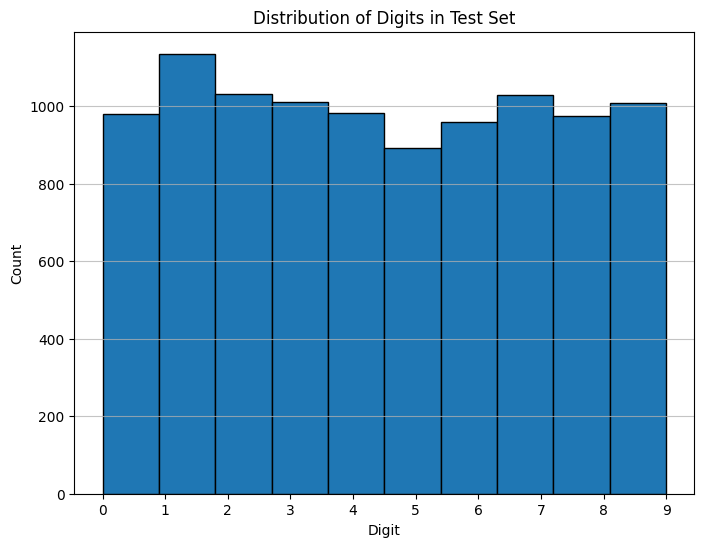

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(test_labels, edgecolor='black')
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Digits in Test Set')
plt.grid(axis='y', alpha=0.75)
plt.savefig('../output/digit_distribution.png', dpi=150)
plt.show()


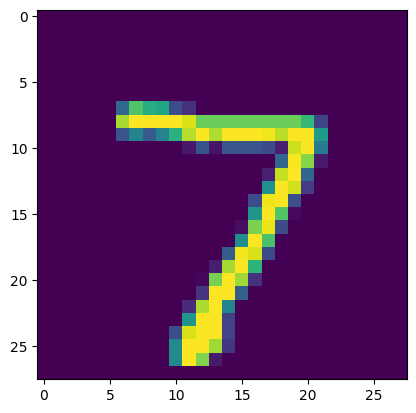

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(test_images[0,0])
plt.show()

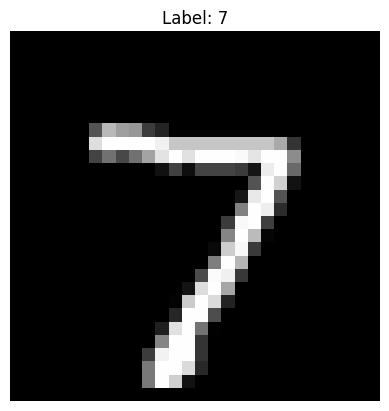

In [9]:
import matplotlib.pyplot as plt

plt.imshow(test_images[0, 0], cmap='gray')
plt.title(f"Label: {test_labels[0]}")
plt.axis('off')
plt.savefig(f'../output/sample_image_label_{test_labels[0]}.png', dpi=150)
plt.show()


(10000, 1, 28, 28)


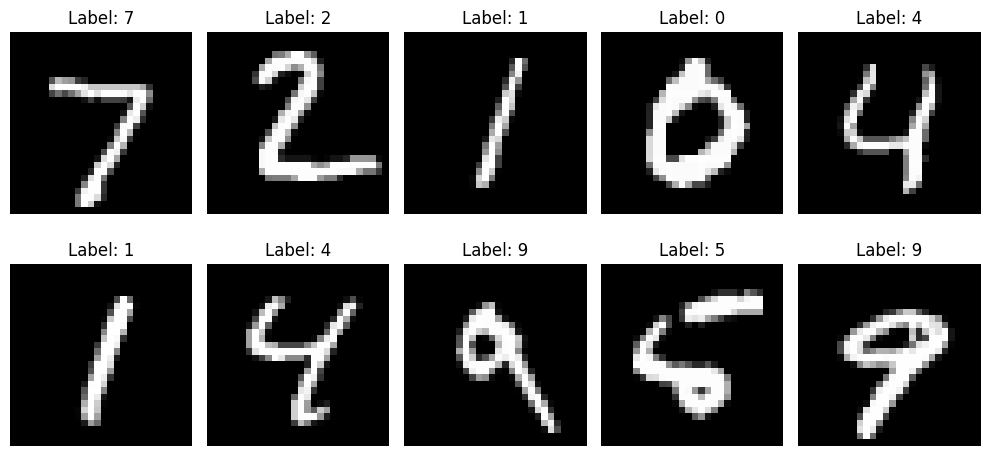

In [10]:
import matplotlib.pyplot as plt

print(test_images.shape)   

# test_images' shape is (N, 1, 28, 28)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = test_images[i, 0] if test_images.ndim == 4 else test_images[i]
    img_display = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f"Label: {test_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images.png', dpi=150)
plt.show()

# Modeling 
Definingn a Convolutional neural network (cnn)

In [11]:
test_images_cnn = test_images.reshape((-1, 28, 28, 1))
print(test_images_cnn.shape)

(10000, 28, 28, 1)


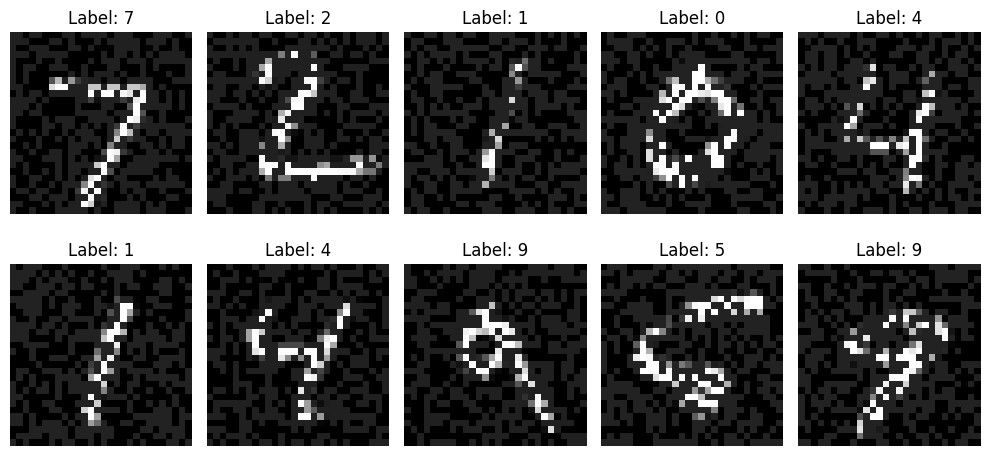

In [12]:
drop_prob = 0.5
drop_mask = np.random.rand(*test_images_cnn.shape) > drop_prob
test_images_dropped = test_images_cnn * drop_mask


plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = test_images_dropped[i, :, :, 0]
    img_display = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img_display, cmap='gray')
    plt.title(f"Label: {test_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images_dropped.png', dpi=150)
plt.show()


In [13]:
from tensorflow.keras import layers, models

drop_prob = 0.5
model = models.Sequential([
    layers.Conv2D(
        filters=32, 
        kernel_size=(3, 3),
        activation='relu', 
        input_shape=(28, 28, 1)
        ),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(drop_prob),
    layers.Dense(10, activation='softmax')
])  
model.summary()


/workspace/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [15]:
epochs = 10  
batch_size = 200
learn_rate = 0.001

fit_model = model.fit(
    test_images_cnn,
    test_labels,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    validation_split = 0.2
    )

print(f"Final training accuracy: {fit_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_model.history['val_loss'][-1]:.4f}")

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4329 - loss: 1.6551 - val_accuracy: 0.8780 - val_loss: 0.6334
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7673 - loss: 0.7143 - val_accuracy: 0.9485 - val_loss: 0.2487
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.8487 - loss: 0.4698 - val_accuracy: 0.9620 - val_loss: 0.1577
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8914 - loss: 0.3527 - val_accuracy: 0.9730 - val_loss: 0.1097
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9066 - loss: 0.2969 - val_accuracy: 0.9750 - val_loss: 0.0976
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9255 - loss: 0.2456 - val_accuracy: 0.9795 - val_loss: 0.0765
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9291 - loss: 0.2263 - val_accuracy: 0.9815 - val_loss: 0.0714
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9359 - loss: 0.2035 - val_accuracy: 0.9815 - v

Pivoting parameters to get better training and validations accuracy, and training and validation loss.

In [16]:
epochs = 20  
batch_size = 64
validation_split = 0.2
learn_rate = 0.001

seed_images = test_images_cnn  # ya en (10000,28,28,1)
seed_labels = test_labels
initial_model = model 


initial_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
    )
fit_initial_model = initial_model.fit(
    seed_images, 
    seed_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
    )

print(f"Final training accuracy: {fit_initial_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_initial_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_initial_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_initial_model.history['val_loss'][-1]:.4f}")


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9455 - loss: 0.1694 - val_accuracy: 0.9850 - val_loss: 0.0564
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9524 - loss: 0.1494 - val_accuracy: 0.9870 - val_loss: 0.0449
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9548 - loss: 0.1474 - val_accuracy: 0.9880 - val_loss: 0.0492
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9574 - loss: 0.1287 - val_accuracy: 0.9875 - val_loss: 0.0435
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9616 - loss: 0.1162 - val_accuracy: 0.9880 - val_loss: 0.0412
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9639 - loss: 0.1132 - val_accuracy: 0.9890 - val_loss: 0.0397
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9644 - loss: 0.1066 - val_accuracy: 0.9875 - val_loss: 0.0376
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9672 - loss: 0.0964 - val_accurac

In [17]:
train_images = images_extractor(trainset)  # (60000, 1, 28, 28)
initial_model.fit(
    seed_images, 
    seed_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
    )

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9787 - loss: 0.0620 - val_accuracy: 0.9900 - val_loss: 0.0293
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9814 - loss: 0.0571 - val_accuracy: 0.9925 - val_loss: 0.0234
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9803 - loss: 0.0591 - val_accuracy: 0.9895 - val_loss: 0.0295
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9812 - loss: 0.0570 - val_accuracy: 0.9875 - val_loss: 0.0308
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9809 - loss: 0.0547 - val_accuracy: 0.9895 - val_loss: 0.0313
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9820 - loss: 0.0592 - val_accuracy: 0.9905 - val_loss: 0.0294
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9821 - loss: 0.0573 - val_accuracy: 0.9910 - val_loss: 0.0285
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9840 - loss: 0.0512 - val_accur

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


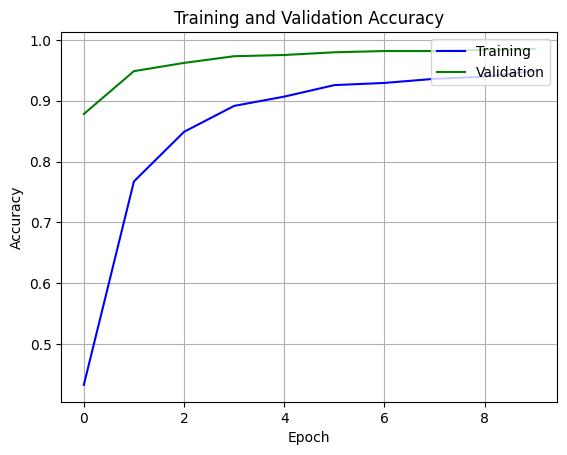

In [18]:
import matplotlib.pyplot as plt

_ = model.predict(test_images_cnn[:1])

plt.plot(fit_model.history['accuracy'], c="b", label='Train Accuracy')
plt.plot(fit_model.history['val_accuracy'], c="g", label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.savefig('../output/accuracy_plot.png', dpi=150)
plt.show()

# Evaluation

In [20]:
ACC = model.evaluate(test_images_cnn, test_labels, verbose=0)
print(f"Test accuracy: {ACC[1]:.4f}")


Test accuracy: 0.9983


# Embedding

In [21]:
import tensorflow as tf

layer_names = [layer.name for layer in initial_model.layers]
print(layer_names)

dense_layers = [layer.name for layer in initial_model.layers 
                if isinstance(layer, tf.keras.layers.Dense)]
print("Available Dense layzers:", dense_layers)
selected_layer = dense_layers[-1]
print(selected_layer)


['conv2d', 'max_pooling2d', 'dropout', 'conv2d_1', 'max_pooling2d_1', 'dropout_1', 'flatten', 'dense', 'dropout_2', 'dense_1']
Available Dense layzers: ['dense', 'dense_1']
dense_1


In [22]:
import tensorflow as tf

embedding_model = tf.keras.Model(
    inputs=initial_model.inputs, 
    outputs=initial_model.get_layer(selected_layer).output
    )
train_embeddings = embedding_model.predict(
    train_images.reshape(-1,28,28,1)
    )  # shape (60000, 128      )

  90/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

2026-06-22 13:47:04.800697: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


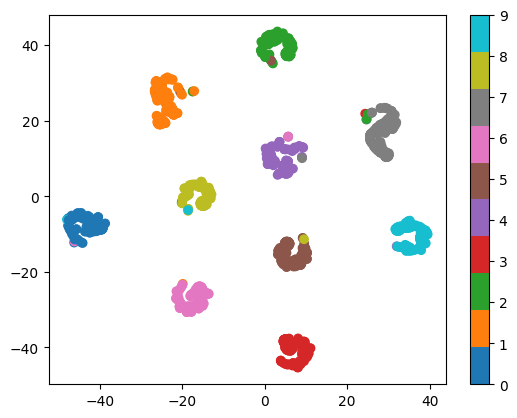

In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

train_labels = labels_extractor(trainset)

tsne = TSNE(n_components=2)
embeddings_2d = tsne.fit_transform(train_embeddings[:1000])  # Only first n-ones

plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=train_labels[:1000], 
    cmap='tab10'
    )
plt.colorbar()
plt.show()

#bit of a cheating :)

Every point is the 2d-projection from `dense_2` layer within the initial model. We can already see the digits by their colours and how for instance `4` and `9` are way too close and the model may be confused about those labels (the result labels). 

So this is a visualization that allows us to understand _how good the model is acting_, and the overlappings will be the places where I shall take attention to. 

# Projections and clusterization

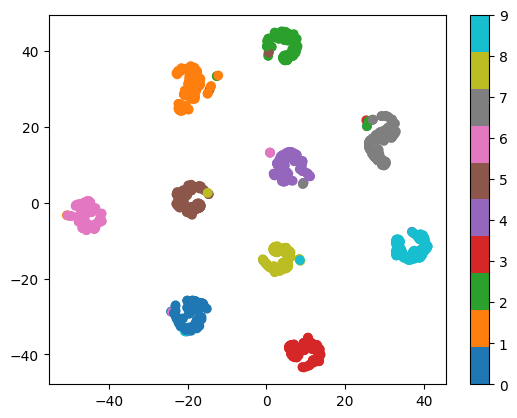

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

train_labels = labels_extractor(trainset)

tsne = TSNE(n_components=2)
embeddings_2d = tsne.fit_transform(train_embeddings[:1000])  # Only first n-ones

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=train_labels[:1000], cmap='tab10')
plt.colorbar()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

n_components = min(
    50, 
    train_embeddings.shape[0],
    train_embeddings.shape[1]
    )
pca = PCA(n_components=n_components)
train_pca = pca.fit_transform(train_embeddings)

tsne = TSNE(n_components=2, random_state=42)
train_tsne = tsne.fit_transform(train_pca)

# Visualization
plt.scatter(
    train_tsne[:,0], 
    train_tsne[:,1],
    c='gray',
    alpha=0.2
    )
plt.show()

# Clustering
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
    )
cluster_labels = kmeans.fit_predict(train_embeddings)  # o usar train_pca

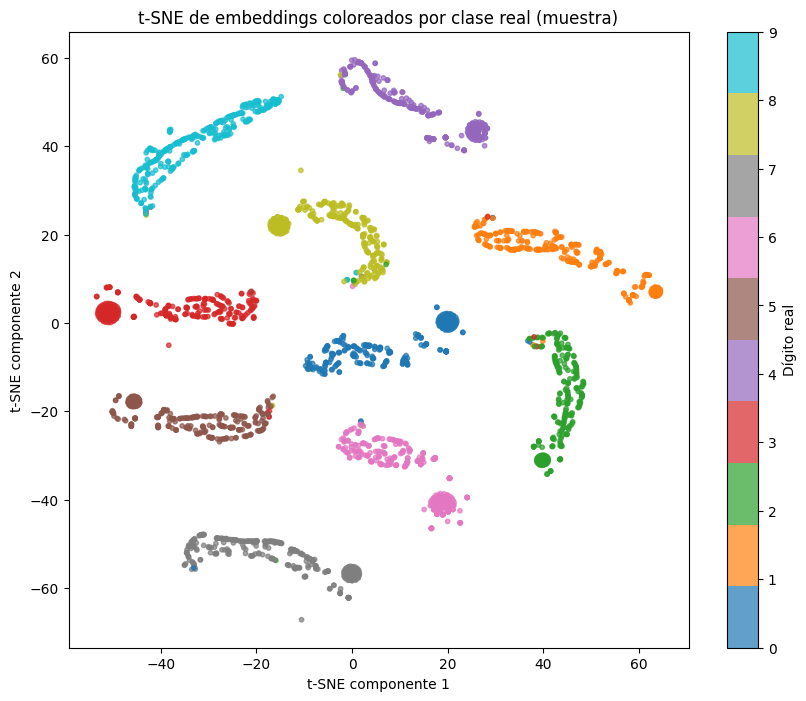

In [ ]:
# Asumimos que train_embeddings y train_true_labels existen (groundtruth, solo para evaluación)
# randomization haciendo trampa porque se usan las true_labels

train_true_labels = train_labels
n_components = min(
    50, 
    train_embeddings.shape[0],
    train_embeddings.shape[1]
    )


sample_size = 3000   # ajustar según memoria/tiempo
np.random.seed(42)
indices = np.random.choice(train_embeddings.shape[0], sample_size, replace=False)
sample_embeddings = train_embeddings[indices]
sample_true_labels = train_true_labels[indices]   # solo para inspección


pca = PCA(n_components=n_components)   
sample_pca = pca.fit_transform(sample_embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
sample_tsne = tsne.fit_transform(sample_pca)


plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    sample_tsne[:, 0], 
    sample_tsne[:, 1], 
    c=sample_true_labels,
    cmap='tab10',
    alpha=0.7,
    s=10
    )
plt.colorbar(scatter, ticks=range(10), label='Dígito real')
plt.title("t‑SNE de embeddings coloreados por clase real (muestra)")
plt.xlabel("t‑SNE componente 1")
plt.ylabel("t‑SNE componente 2")
plt.show()

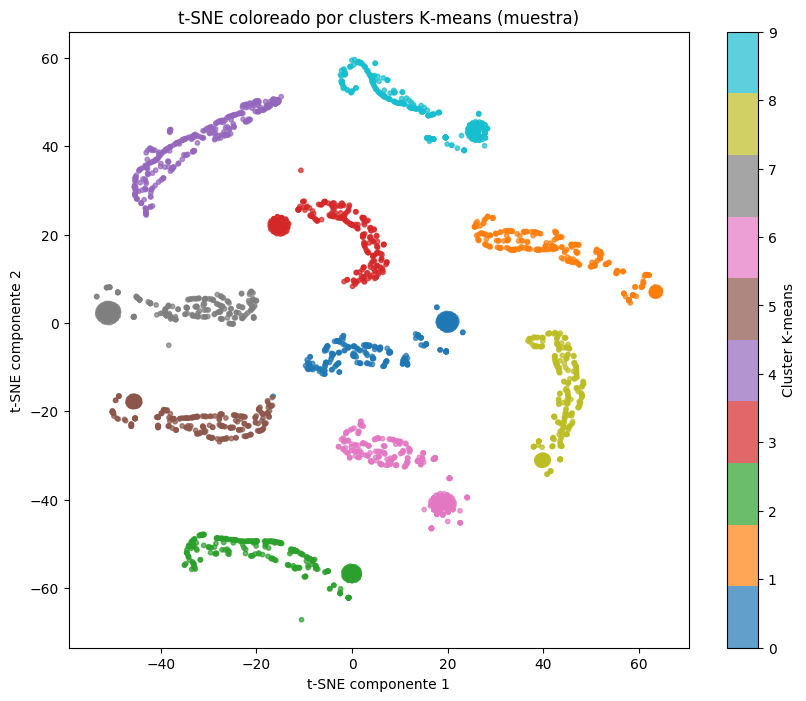

In [ ]:
#6. Clustering con K‑means (sobre los embeddings originales, no sobre la proyección)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
# Si quieres clustering sobre la muestra, pero luego asignarás a todo el conjunto
sample_cluster_labels = kmeans.fit_predict(sample_embeddings)  # o usar sample_pca

#7. Visualizar por clusters (aún sin asignar clases)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(sample_tsne[:, 0], sample_tsne[:, 1], 
                      c=sample_cluster_labels, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Cluster K‑means')
plt.title("t‑SNE coloreado por clusters K‑means (muestra)")
plt.xlabel("t‑SNE componente 1")
plt.ylabel("t‑SNE componente 2")
plt.show()



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


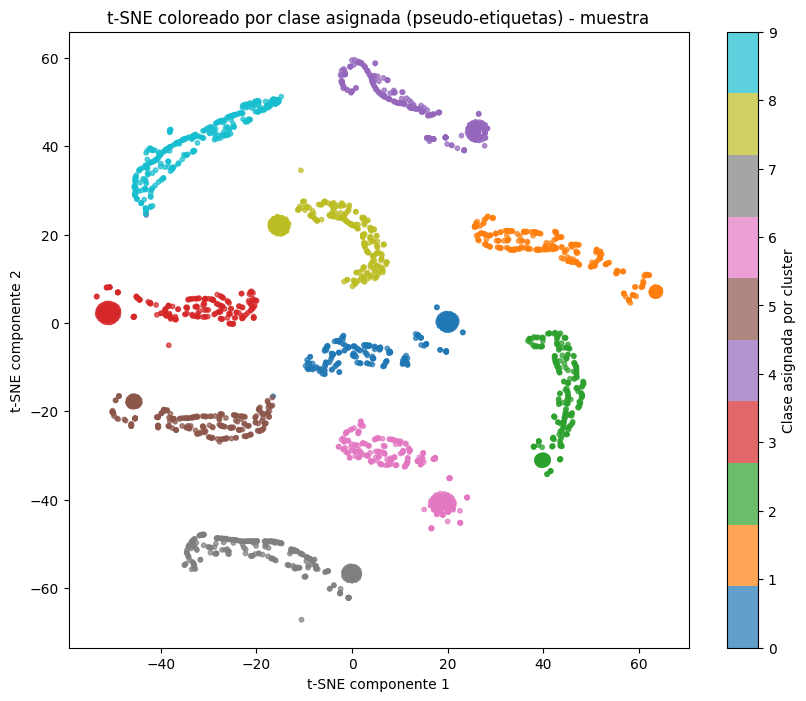

In [ ]:
#8. Asignar clases a los clusters usando la semilla (conjunto de test)
# Obtener embeddings de la semilla (test) usando el mismo modelo de embedding
seed_embeddings = embedding_model.predict(test_images.reshape(-1,28,28,1))  # shape (10000, 128)
seed_labels = test_labels   # reales de test

# Calcular centroide de cada clase en el espacio de embeddings
class_means = {}
for c in range(10):
    mask = (seed_labels == c)
    if np.sum(mask) > 0:
        class_means[c] = np.mean(seed_embeddings[mask], axis=0)
    else:
        class_means[c] = None

# Calcular centroides de los clusters sobre el conjunto de entrenamiento completo
# (mejor usar todos los datos, no solo la muestra)
full_cluster_labels = kmeans.fit_predict(train_embeddings)  # o si ya lo tienes, reutilizar
cluster_centers = []
for k in range(10):
    mask = (full_cluster_labels == k)
    if np.sum(mask) > 0:
        center = np.mean(train_embeddings[mask], axis=0)
    else:
        center = None
    cluster_centers.append(center)

# Asignar a cada cluster la clase cuyo centroide esté más cerca (distancia euclídea)
cluster_to_class = {}
for k, center in enumerate(cluster_centers):
    if center is not None:
        distances = {c: np.linalg.norm(center - class_means[c]) for c in range(10) if class_means[c] is not None}
        assigned_class = min(distances, key=distances.get)
        cluster_to_class[k] = assigned_class
    else:
        # cluster vacío (poco probable)
        cluster_to_class[k] = -1

# Etiquetas pseudo para todo el conjunto de entrenamiento
pseudo_labels_full = np.array([cluster_to_class[cl] for cl in full_cluster_labels])


#9. Visualizar los puntos de la muestra coloreados por la clase asignada por cluster
# Para la muestra, obtenemos las clases asignadas
sample_pseudo_labels = pseudo_labels_full[indices]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(sample_tsne[:, 0], sample_tsne[:, 1], 
                      c=sample_pseudo_labels, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Clase asignada por cluster')
plt.title("t‑SNE coloreado por clase asignada (pseudo‑etiquetas) - muestra")
plt.xlabel("t‑SNE componente 1")
plt.ylabel("t‑SNE componente 2")
plt.show()



In [ ]:
import numpy as np
import umap
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

embeddings = embeddings_2d
n_neighbors=15 
min_dist=0.1

#projecting
reducer = umap.UMAP(
    n_neighbors=n_neighbors, 
    min_dist=min_dist
    )
project_to_2d = reducer.fit_transform(embeddings)

#clustering
n_clusters=10
kmeans = KMeans(
    n_clusters=n_clusters, 
    random_state=42
    )

cluster_labels = kmeans.fit_predict(embeddings)
cluster_embeddings = cluster_labels



/workspace/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/workspace/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


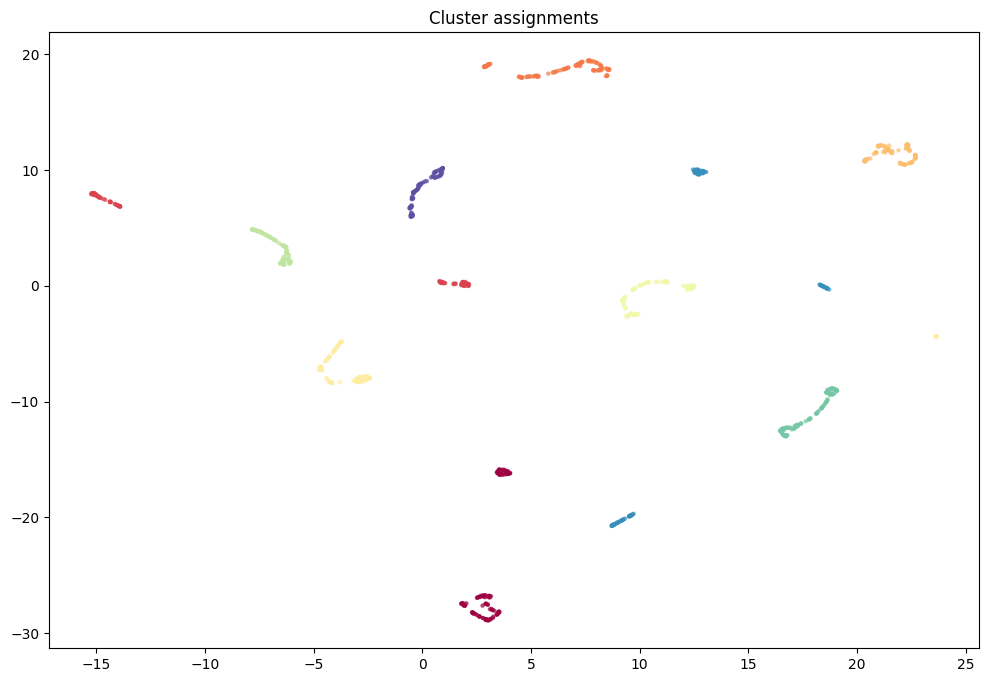

In [ ]:
import matplotlib.pyplot as plt

projected_embeddings = project_to_2d
true_labels=None 
save_path=None

plt.figure(figsize=(12, 8))
    
if true_labels is not None:
    plt.scatter(
        projected_embeddings[:, 0],
        projected_embeddings[:, 1], 
        c=true_labels,
        cmap='Spectral',
        s=5,
        alpha=0.6
        )
    plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    plt.title("True labels")
else:
    plt.scatter(
        projected_embeddings[:, 0],
        projected_embeddings[:, 1], 
        c=cluster_labels,
        cmap='Spectral', 
        s=5, 
        alpha=0.6
        )
    plt.title("Cluster assignments")

if save_path:
    plt.savefig(save_path)
else:
    plt.show()
plt.close()


Entrenando KMeans (k=10)...
 Clusters: 10, Ruido: 0, Silueta: 0.8165658116340637, ARI: None


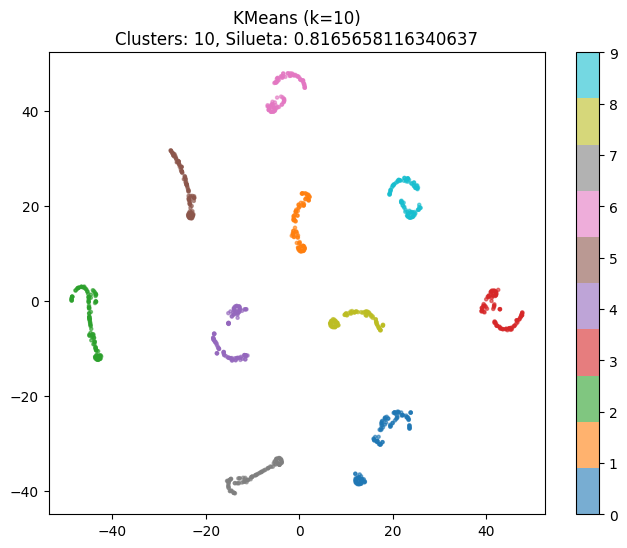

Entrenando DBSCAN (eps=0.5)...
 Clusters: 47, Ruido: 534, Silueta: -0.1699368953704834, ARI: None


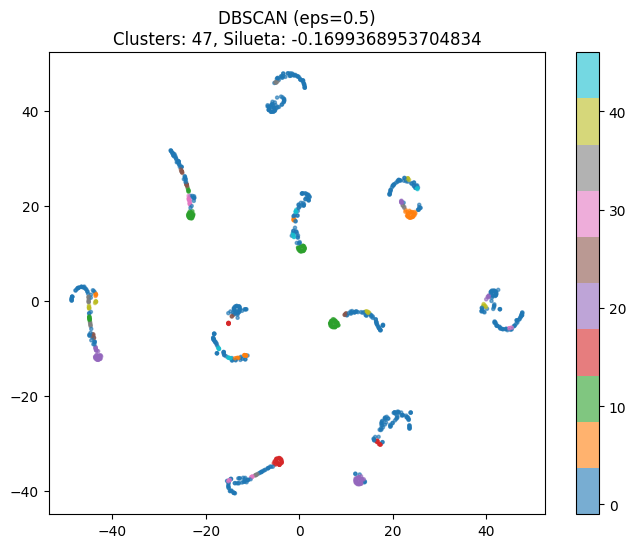

Entrenando DBSCAN (eps=0.7)...
 Clusters: 62, Ruido: 309, Silueta: 0.14675571024417877, ARI: None


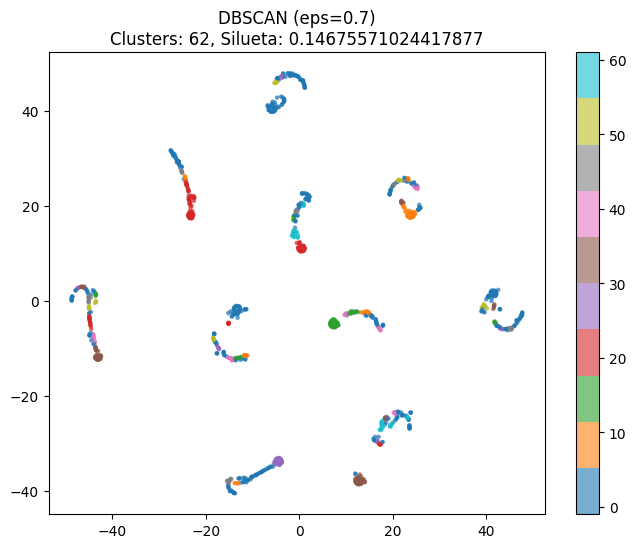

Entrenando Agglomerative (k=10)...
 Clusters: 10, Ruido: 0, Silueta: 0.8165658116340637, ARI: None


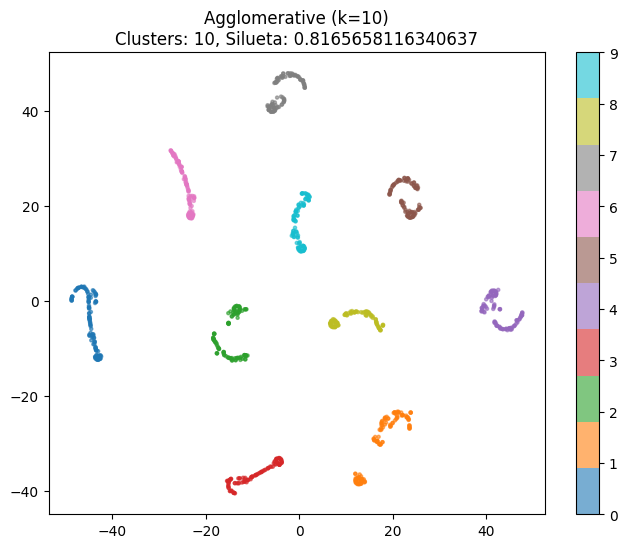

In [ ]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt


def evaluate_clustering(embeddings, true_labels=None, sample_size=3000):
    """
    Prueba varios algoritmos de clustering sobre los embeddings.
    Muestra métricas y visualiza con t‑SNE (o UMAP).
    """
    # Tomar una muestra si es muy grande
    if embeddings.shape[0] > sample_size:
        indices = np.random.choice(embeddings.shape[0], sample_size, replace=False)
        X_sample = embeddings[indices]
        y_true_sample = true_labels[indices] if true_labels is not None else None
    else:
        X_sample = embeddings
        y_true_sample = true_labels

    # Algoritmos a probar
    algorithms = {
        'KMeans (k=10)': KMeans(n_clusters=10, random_state=42, n_init=10),
        'DBSCAN (eps=0.5)': DBSCAN(eps=0.5, min_samples=5),
        'DBSCAN (eps=0.7)': DBSCAN(eps=0.7, min_samples=5),
        'Agglomerative (k=10)': AgglomerativeClustering(n_clusters=10),
    }

    # Reducción para visualización (t‑SNE)
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_vis = tsne.fit_transform(X_sample)

    results = {}
    for name, model in algorithms.items():
        print(f"Entrenando {name}...")
        labels = model.fit_predict(X_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1) if hasattr(model, 'eps') else 0

        # Métricas
        sil = silhouette_score(X_sample, labels) if n_clusters >= 2 and n_clusters < len(X_sample) else None
        ari = adjusted_rand_score(y_true_sample, labels) if y_true_sample is not None else None

        results[name] = {
            'labels': labels,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil,
            'ARI': ari
        }
        print(f" Clusters: {n_clusters}, Ruido: {n_noise}, Silueta: {sil}, ARI: {ari}")

        # Visualización
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='tab10', s=5, alpha=0.6)
        plt.colorbar(scatter)
        plt.title(f"{name}\nClusters: {n_clusters}, Silueta: {sil}")
        plt.show()

    return results

result = evaluate_clustering(embeddings=embeddings)


Checking out different clusterization methods, the worst is DBSCAN, but we can continue better with KMeans to the matter of this task. 

KMeans has:

Entrenando KMeans (k=10)...
 Clusters: 10, Ruido: 0, Silueta: 0.8165658116340637, ARI: None

no noise, simplicity and a hight silouette. 

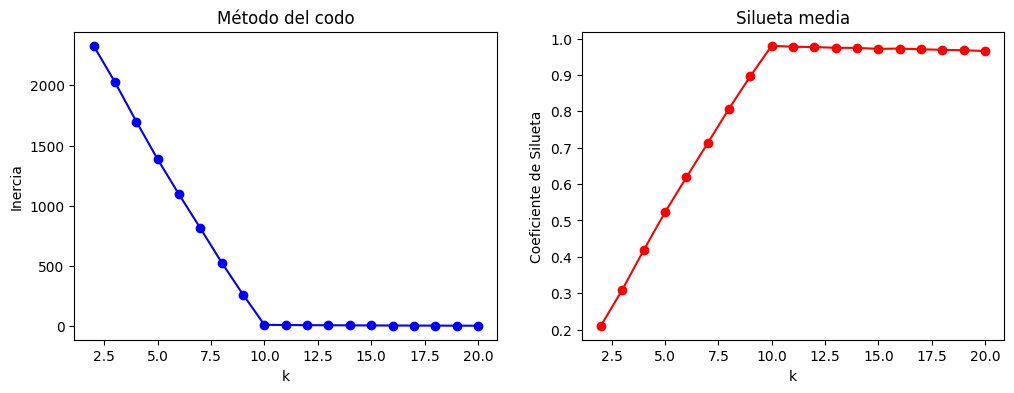

In [ ]:
from sklearn.metrics import silhouette_score

def optimal_k_analysis(embeddings, max_k=20, sample_size=3000):
    """
    Calcula inercia y silhouette para k de 2 a max_k sobre una muestra.
    """
    if embeddings.shape[0] > sample_size:
        indices = np.random.choice(embeddings.shape[0], sample_size, replace=False)
        X_sample = embeddings[indices]
    else:
        X_sample = embeddings

    inertias = []
    silhouettes = []
    K_range = range(2, max_k+1)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_sample)
        inertias.append(kmeans.inertia_)
        sil = silhouette_score(X_sample, labels)
        silhouettes.append(sil)

    # Graficar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(K_range, inertias, 'bo-')
    ax1.set_xlabel('k')
    ax1.set_ylabel('Inercia')
    ax1.set_title('Método del codo')

    ax2.plot(K_range, silhouettes, 'ro-')
    ax2.set_xlabel('k')
    ax2.set_ylabel('Coeficiente de Silueta')
    ax2.set_title('Silueta media')
    plt.show()

    return inertias, silhouettes

# Ejecutar
inertias, silhouettes = optimal_k_analysis(train_embeddings, max_k=20)